<a href="https://colab.research.google.com/github/leonardocontegeografia-max/UENFMestrado/blob/main/Acai%2Bbarbeiro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================================================
# 1. Instalação das bibliotecas
# =========================================================
!pip install roboflow
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 65.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.0 MB/s eta 0:00:00


In [2]:
# =========================================================
# 2. Configuração única do Roboflow (SUA IDENTIDADE - usada apenas aqui)
# =========================================================
from roboflow import Roboflow

ROBOFLOW_API_KEY = "sN1Mziu1XQQv9wllCQJy"
WORKSPACE = "leonardo-conte"
PROJECT_NAME = "my-first-project-2mi6p"

VERSION = 3

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT_NAME)

# Opcional: listar versões disponíveis do projeto
print(f"Versões disponíveis para o projeto '{project.name}':")
for v in project.versions():
    print(f"- Versão {v.version}: {v.name}")

loading Roboflow workspace...
loading Roboflow project...
Versões disponíveis para o projeto 'My First Project':
- Versão 3: My First Project
- Versão 2: My First Project
- Versão 1: My First Project


In [3]:
# =========================================================
# 3. Download do dataset (açaí + barbeiro)
# =========================================================
version = project.version(VERSION)
dataset = version.download("yolov11")

print("Dataset baixado em:", dataset.location)


Extracting Dataset Version Zip to My-First-Project-3 in yolov11:: 100%|██████████| 68/68 [00:00<00:00, 4185.50it/s]

Dataset baixado em: /content/My-First-Project-3


In [4]:
# =========================================================
# 4. Ajuste do data.yaml (caminhos absolutos corretos)
# =========================================================
import os
import yaml

data_yaml_path = os.path.join(dataset.location, 'data.yaml')

with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Remove a entrada 'path' problemática, se existir
if 'path' in data_config:
    print(f"Removendo a entrada 'path' problemática do data.yaml: {data_config['path']}")
    del data_config['path']

if 'train' in data_config:
    data_config['train'] = os.path.join(dataset.location, 'train')
if 'val' in data_config:
    # O Roboflow costuma nomear a pasta de validação como 'valid'
    data_config['val'] = os.path.join(dataset.location, 'valid')
if 'test' in data_config:
    data_config['test'] = os.path.join(dataset.location, 'test')

print("Classes detectadas no dataset:", data_config.get('names'))
print("Número de classes:", data_config.get('nc'))

# Salva o data.yaml ajustado
temp_data_yaml_path = os.path.join(dataset.location, 'data_modified_ultralytics.yaml')
with open(temp_data_yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print(f"data.yaml modificado salvo em: {temp_data_yaml_path}")
print("Conteúdo do data.yaml modificado:")
with open(temp_data_yaml_path, 'r') as f:
    print(f.read())

Classes detectadas no dataset: ['assai', 'barbeiro', 'object']
Número de classes: 3
data.yaml modificado salvo em: /content/My-First-Project-3/data_modified_ultralytics.yaml
Conteúdo do data.yaml modificado:
names:
- assai
- barbeiro
- object
nc: 3
roboflow:
  license: CC BY 4.0
  project: my-first-project-2mi6p
  url: https://universe.roboflow.com/leonardo-conte/my-first-project-2mi6p/dataset/3
  version: 3
  workspace: leonardo-conte
test: /content/My-First-Project-3/test
train: /content/My-First-Project-3/train
val: /content/My-First-Project-3/valid



In [5]:
# =========================================================
# 5. Treinamento do modelo (açaí + barbeiro)
# =========================================================
from ultralytics import YOLO

model = YOLO("yolo11l-seg.pt")  # modelo base de segmentação

model.train(
    data=temp_data_yaml_path,
    epochs=30,        # <<< ALTERADO: era 5, aumentado para o modelo aprender melhor
    imgsz=960,         # <<< ALTERADO: era 640 (você já tinha mudado no seu ambiente)
    batch=16,
    workers=8,
    patience=10,       # <<< NOVO: para o treino cedo se não melhorar em 10 épocas seguidas
    seed=42,           # <<< NOVO: fixa a semente para resultados reproduzíveis
    project=PROJECT_NAME,
    name="exp_acai_barbeiro"
)

# <<< CORRIGIDO: pega o caminho do best.pt dinamicamente (não hardcoded),
# pois o Ultralytics salva em runs/segment/... e adiciona sufixo (-2, -3, -4...)
# toda vez que a pasta já existe de um treino anterior
best_model_path = model.trainer.best
model = YOLO(best_model_path)
print(f"Melhor modelo carregado de: {best_model_path}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/My-First-Project-3/data_modified_ultralytics.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11l-seg summary (fused): 204 layers, 27,586,905 parameters, 0 gradients, 131.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1602.3±394.9 MB/s, size: 70.1 KB)
val: Scanning /content/My-First-Project-3/valid/labels.cache... 2 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2/2 699.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.3it/s 0.4s
                   all          2          4       0.15      0.667      0.428      0.204       0.15      0.667      0.345      0.194
                 assai          2          3      0.299      0.333      0.359       0.11      0.299      0.333      0.192     0.0396
              barbeiro          1          1    0.00245          1      0.497      0.298    0.00245          1      0.497      0.348
Speed: 2.2ms preprocess, 115.9ms infe

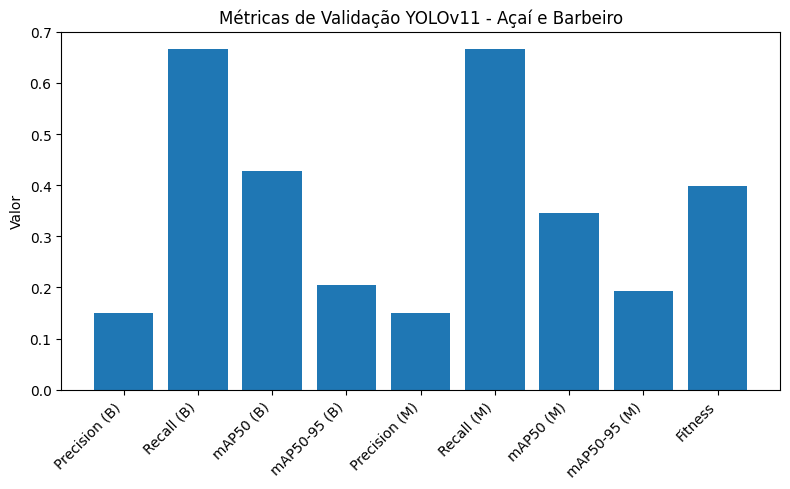

In [6]:
# =========================================================
# 6. Validação e métricas
# =========================================================
metrics = model.val(data=temp_data_yaml_path)
print(metrics)

import matplotlib.pyplot as plt

labels_map = {
    "metrics/precision(B)": "Precision (B)",
    "metrics/recall(B)": "Recall (B)",
    "metrics/mAP50(B)": "mAP50 (B)",
    "metrics/mAP50-95(B)": "mAP50-95 (B)",
    "metrics/precision(M)": "Precision (M)",
    "metrics/recall(M)": "Recall (M)",
    "metrics/mAP50(M)": "mAP50 (M)",
    "metrics/mAP50-95(M)": "mAP50-95 (M)",
    "fitness": "Fitness"
}

keys = list(metrics.results_dict.keys())
values = list(metrics.results_dict.values())
labels = [labels_map.get(k, k) for k in keys]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Valor")
plt.title("Métricas de Validação YOLOv11 - Açaí e Barbeiro")
plt.tight_layout()
plt.show()

In [9]:
import glob
import os

# Pega automaticamente a primeira imagem da pasta de teste do dataset
# (não precisa informar nenhum caminho - já usa o dataset baixado na seção 3)
test_images = glob.glob(os.path.join(dataset.location, "test", "images", "*.*" ))
print(f"Encontradas {len(test_images)} imagens de teste")

if len(test_images) == 0:
    print("Nenhuma imagem de teste encontrada no diretório especificado.")
    print(f"Por favor, verifique se existem imagens em: {os.path.join(dataset.location, 'test', 'images')}")

    # As a fallback, try to use validation images if test images are not available
    print("Tentando usar imagens de validação para predição...")
    val_images = glob.glob(os.path.join(dataset.location, "valid", "images", "*.*" ))
    if len(val_images) > 0:
        print(f"Encontradas {len(val_images)} imagens de validação.")
        # Use the first validation image for prediction
        image_to_predict = val_images[0]
        print(f"Usando a imagem: {image_to_predict} para predição.")
        results = model.predict(image_to_predict, save=True, conf=0.15, iou=0.4)
        # Mostrar máscaras/detecções (açaí e barbeiro)
        results[0].plot()
    else:
        print("Nenhuma imagem de validação encontrada também. Não foi possível realizar a predição.")
else:
    # Original logic: use the first test image for prediction
    image_to_predict = test_images[0]
    print(f"Usando a imagem: {image_to_predict} para predição.")
    results = model.predict(image_to_predict, save=True, conf=0.15, iou=0.4)
    # Mostrar máscaras/detecções (açaí e barbeiro)
    results[0].plot()

Encontradas 0 imagens de teste
Nenhuma imagem de teste encontrada no diretório especificado.
Por favor, verifique se existem imagens em: /content/My-First-Project-3/test/images
Tentando usar imagens de validação para predição...
Encontradas 2 imagens de validação.
Usando a imagem: /content/My-First-Project-3/valid/images/9_jpeg.rf.73561da51da6c8a3f3c4972b17303cea.jpg para predição.

image 1/1 /content/My-First-Project-3/valid/images/9_jpeg.rf.73561da51da6c8a3f3c4972b17303cea.jpg: 960x960 (no detections), 125.6ms
Speed: 6.6ms preprocess, 125.6ms inference, 1.0ms postprocess per image at shape (1, 3, 960, 960)
Results saved to /content/runs/segment/predict
